In [ ]:
import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.switch_backend('Agg')

import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

print('Libraries imported successfully.')

Libraries imported successfully.


## Data Loading

*We load the trasaction data from a csv file. Note that all data files are located in the same directory as this notebook*

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kelvinobiri/credit-card-transactions")

print("Path to dataset files:", path)

100%|██████████| 5.96M/5.96M [00:01<00:00, 5.95MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kelvinobiri/credit-card-transactions/versions/1


In [10]:
from google.colab import files

uploaded = files.upload()


Saving transactions.csv to transactions.csv


In [16]:
# Nombre del archivo cargado, por ejemplo: 'datos.csv'
df = pd.read_csv('transactions.csv')

# Mostrar las primeras filas
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,8,CASH_OUT,158007.12,C424875646,0.00,0.00,C1298177219,474016.32,1618631.97,0
1,236,CASH_OUT,457948.30,C1342616552,0.00,0.00,C1323169990,2720411.37,3178359.67,0
2,37,CASH_IN,153602.99,C900876541,11160428.67,11314031.67,C608741097,3274930.56,3121327.56,0
3,331,CASH_OUT,49555.14,C177696810,10865.00,0.00,C462716348,0.00,49555.14,0
4,250,CASH_OUT,29648.02,C788941490,0.00,0.00,C1971700992,56933.09,86581.10,0


## Data Cleaning and Preprocessing

*Before conducting any analysis, it is important to ensure that the data is clean and ready for analysis. In this section, we check for missing values and inconsistencies*

In [17]:
# Check for missing values
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

# Drop duplicates if any (a common source of error for similar datasets)
initial_shape = df.shape
df.drop_duplicates(inplace=True)
final_shape = df.shape
print(f'Initial shape: {initial_shape}, after dropping duplicates: {final_shape}')

Missing values in each column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64
Initial shape: (199999, 10), after dropping duplicates: (199999, 10)


##Exploratory Data Analysis
*We now dive into some basic exploratory data analysis to understand the distribution of features, correlations between numeric columns, and to visually inspect how fraud cases differ from non-frauduelent ones*

In [18]:
print('Descriptive statistics:')
print(df.describe())

print('\nTransaction type counts:')
print (df['type'].value_counts())

Descriptive statistics:
                step        amount  oldbalanceOrg  newbalanceOrig  \
count  199999.000000  1.999990e+05   1.999990e+05    1.999990e+05   
mean      243.289836  1.802425e+05   8.314361e+05    8.523333e+05   
std       141.800473  6.255482e+05   2.882314e+06    2.917352e+06   
min         1.000000  0.000000e+00   0.000000e+00    0.000000e+00   
25%       156.000000  1.338746e+04   0.000000e+00    0.000000e+00   
50%       238.000000  7.426695e+04   1.420100e+04    0.000000e+00   
75%       334.000000  2.086376e+05   1.078489e+05    1.449629e+05   
max       741.000000  5.204280e+07   5.039905e+07    4.039905e+07   

       oldbalanceDest  newbalanceDest        isFraud  
count    1.999990e+05    1.999990e+05  199999.000000  
mean     1.093644e+06    1.218886e+06       0.001410  
std      3.302878e+06    3.627192e+06       0.037524  
min      0.000000e+00    0.000000e+00       0.000000  
25%      0.000000e+00    0.000000e+00       0.000000  
50%      1.320572e+05   

##Visialization
*Visualization is critical to gain a quick feel for the data. The notebook employs multiple visualization techniques to illustrate patterns and potential signals of fraud*

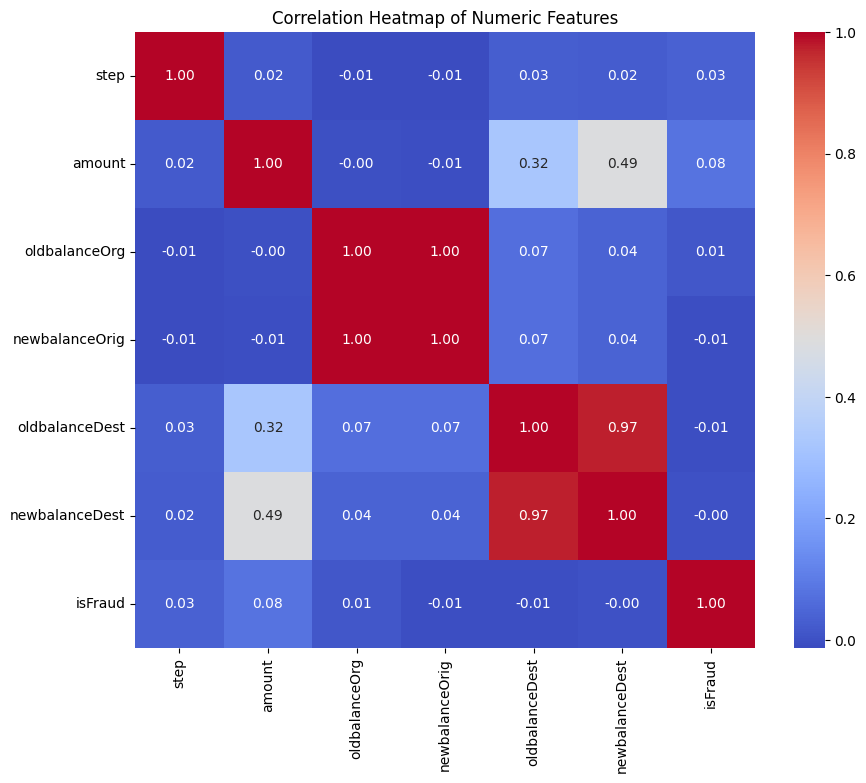

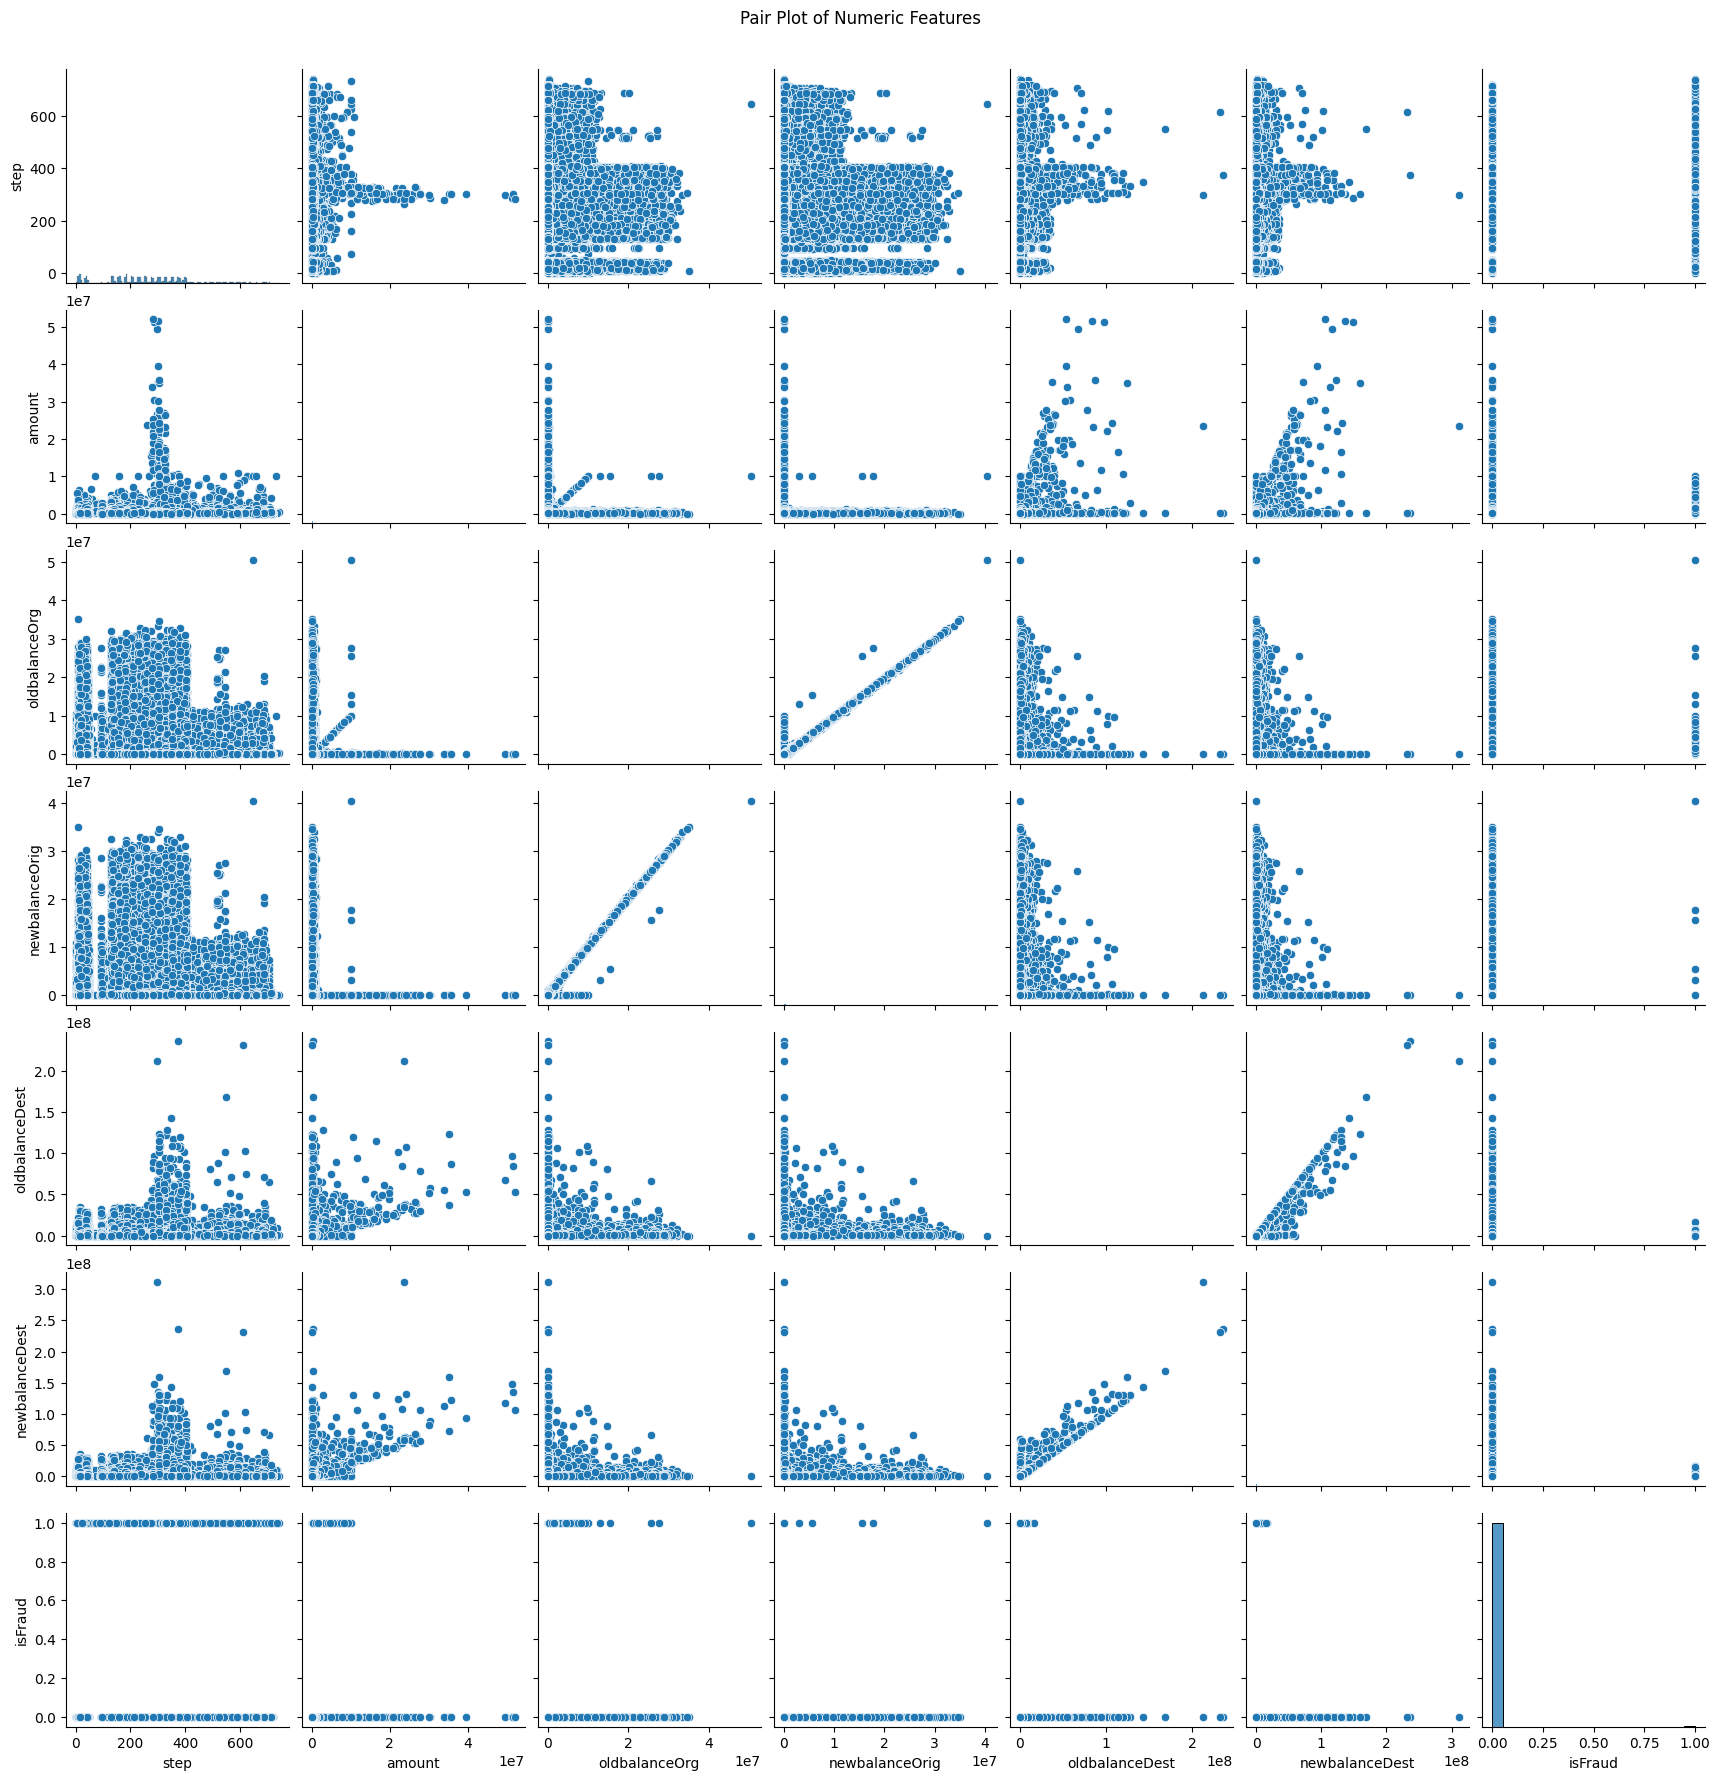

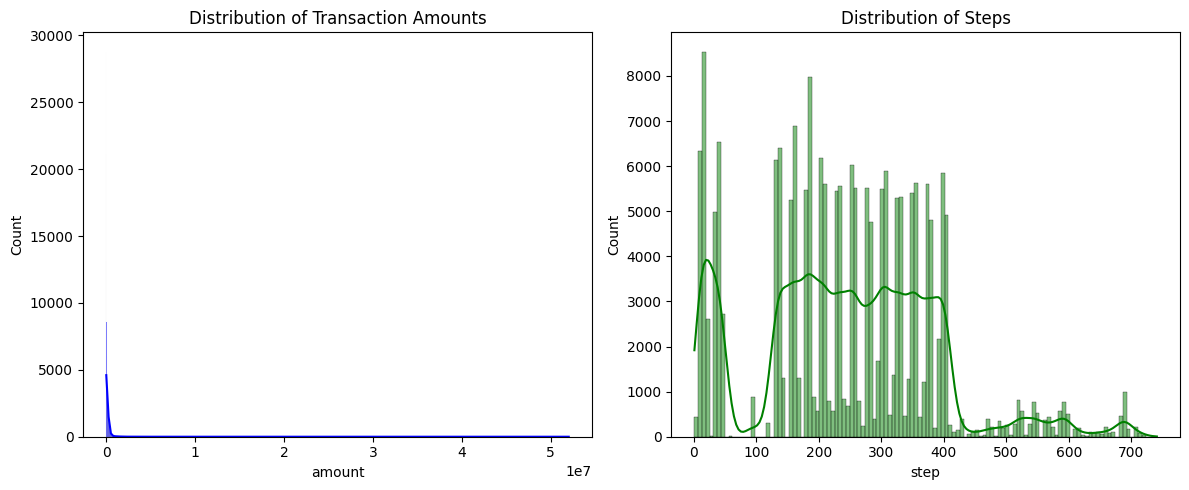

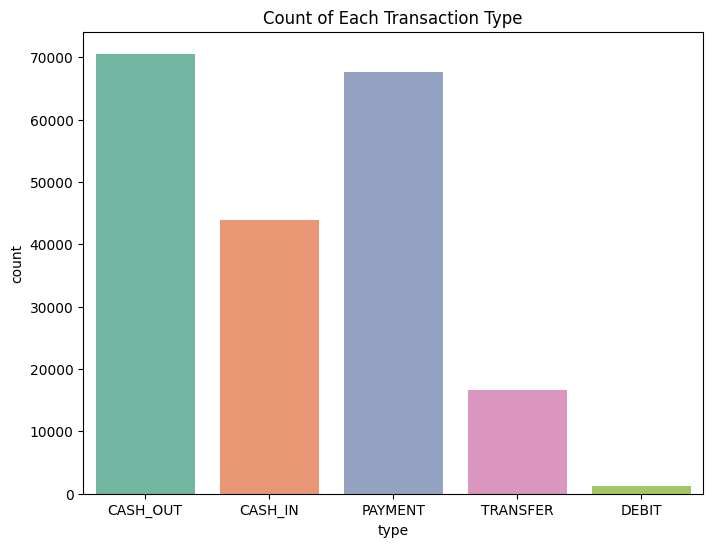

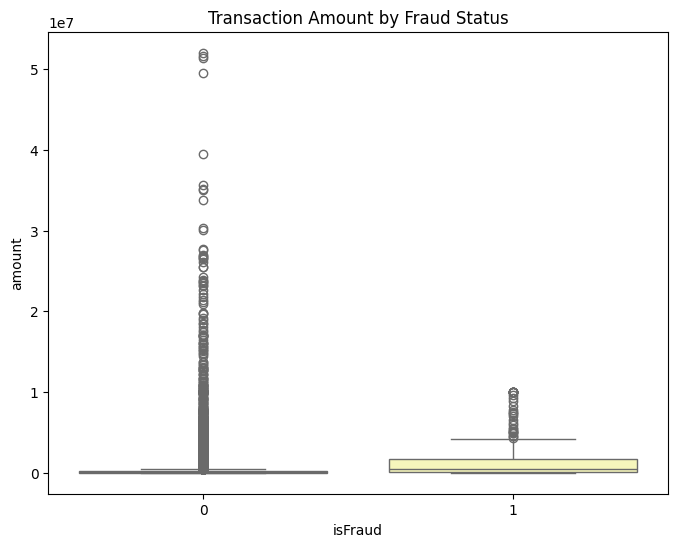

In [19]:
numeric_df = df.select_dtypes(include=[np.number])

if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()
else:
    print('Not enough numeric columns for a correlation heatmap.')

## Pair plot to visualize pairwise relationships
sns.pairplot(numeric_df)
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

## Histogram for 'amount' and 'step'
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['amount'], kde=True, color='blue')
plt.title('Distribution of Transaction Amounts')

plt.subplot(1, 2, 2)
sns.histplot(df['step'], kde=True, color='green')
plt.title('Distribution of Steps')

plt.tight_layout()
plt.show()

## Count Plot (Pie Chart alternative) for Transaction Types
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Count of Each Transaction Type')
plt.show()

## Box Plot of transaction amount by fraud status
plt.figure(figsize=(8, 6))
sns.boxplot(x='isFraud', y='amount', data=df, palette='Set3')
plt.title('Transaction Amount by Fraud Status')
plt.show()

## Predictive Modeling

*We now shift gears to building a simple fraud predictor. A logistic regression model is used to classify transactions as either fraudulent or not. Data preprocessing includes one-hot encoding for the categorical variable 'type' and scaling numerical features. The model's accuracy and confusion matrix will be evaluated.*

Prediction Accuracy: 0.9990


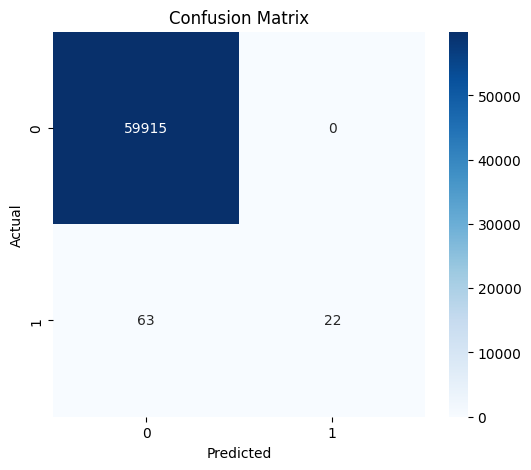


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59915
           1       1.00      0.26      0.41        85

    accuracy                           1.00     60000
   macro avg       1.00      0.63      0.71     60000
weighted avg       1.00      1.00      1.00     60000



In [20]:
# Prepare data for predictive modeling
df_model = df.copy()

# One-hot encode the categorical feature 'type'
df_model = pd.get_dummies(df_model, columns=['type'], drop_first=True)

# Define features X and target y
X = df_model.drop(['isFraud', 'nameOrig', 'nameDest'], axis=1)
y = df_model['isFraud']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = lr_model.predict(X_test_scaled)

# Evaluate the model
acc = accuracy_score(y_test, y_pred)
print(f'Prediction Accuracy: {acc:.4f}')

# Display the confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print classification report for more detailed scores
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

## Conslusion and Future Work
In this notebook, a thorough analysis of credit card transactions was conducted. We explored the data using several visualization techniques including heatmaps, pair plots, histograms, and more. A logistic regression model was built for fraud prediction yielding an accuracy score that could be further improved upon.

The approach used here underscores the value of combining exploratory analysis with predictive modeling. Future work might include:

* Experimenting with more advanced classification models (e.g., Random Forest, XGBoost) to handle imbalanced classes better.

* Further feature engineering and selection, possibly using permutation importance or SHAP values to determine impactful features.

* Incorporating time-based analysis if additional date/time fields are available.